# Practice Lab G: A/B Testing Mini-Project

**Area:** statistics · **Related lessons/concepts:** L52–L54; Quiz 14; Homework 14

**You will be able to:**


In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Simulate session durations

31.08611831005837 34.25085270225656


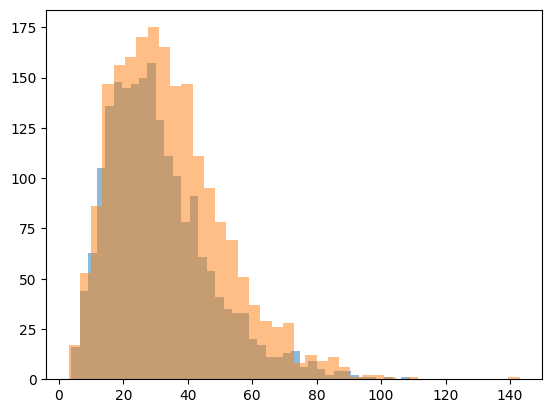

In [2]:
from scipy import stats
rng=np.random.default_rng(7)
ctrl=rng.gamma(4,8.0,2000); var=rng.gamma(4,8.6,2000)
print(ctrl.mean(),var.mean()); plt.hist(ctrl,bins=40,alpha=.5); plt.hist(var,bins=40,alpha=.5); plt.show()

## 2. Welch t-test by hand and with SciPy

In [3]:
def welch(a,b):
    n1,n2=len(a),len(b); s1,s2=a.var(ddof=1),b.var(ddof=1); se=np.sqrt(s1/n1+s2/n2)
    t=(a.mean()-b.mean())/se; df=(s1/n1+s2/n2)**2/((s1/n1)**2/(n1-1)+(s2/n2)**2/(n2-1)); return t,df
t,df=welch(ctrl,var); print(t,df,2*stats.t.sf(abs(t),df)); print(stats.ttest_ind(ctrl,var,equal_var=False))

-6.039771061312291 3978.5153683266853 1.6846627750509195e-09
TtestResult(statistic=np.float64(-6.039771061312291), pvalue=np.float64(1.6846627750509195e-09), df=np.float64(3978.5153683266853))


## 3. Conversion rates

In [4]:
x1,n1,x2,n2=210,2000,260,2000
p1,p2=x1/n1,x2/n2; pp=(x1+x2)/(n1+n2); z=(p1-p2)/np.sqrt(pp*(1-pp)*(1/n1+1/n2)); print(z,2*stats.norm.sf(abs(z)))
se=np.sqrt(p2*(1-p2)/n2); print("CI for variation:",(p2-1.96*se,p2+1.96*se))

-2.4550690893782687 0.014085751373490453
CI for variation: (np.float64(0.11526085212775175), np.float64(0.14473914787224826))


## 4. False-positive rate and power

effect 0 (should be ~0.05): 0.056666666666666664


{10: np.float64(0.15866666666666668), 20: np.float64(0.33866666666666667), 40: np.float64(0.6113333333333333), 80: np.float64(0.894), 160: np.float64(0.992)}


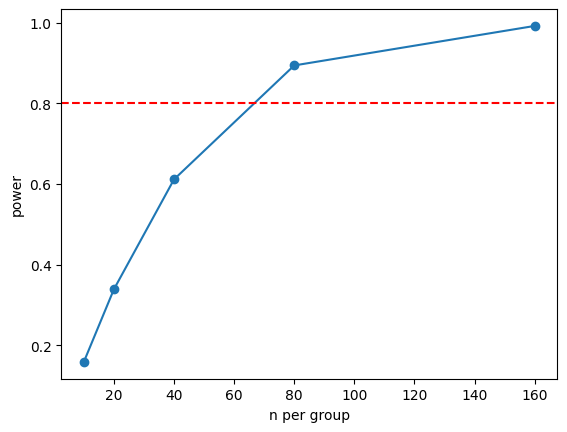

In [5]:
def reject(effect,n,trials=1500):
    c=0
    for _ in range(trials):
        a=rng.normal(0,1,n); b=rng.normal(effect,1,n); c+=stats.ttest_ind(a,b,equal_var=False).pvalue<0.05
    return c/trials
print("effect 0 (should be ~0.05):",reject(0,50))
ns=[10,20,40,80,160]; pw=[reject(0.5,n) for n in ns]; print(dict(zip(ns,pw)))
plt.plot(ns,pw,'o-'); plt.axhline(.8,c='r',ls='--'); plt.xlabel('n per group'); plt.ylabel('power'); plt.show()

## Exercises

**Exercise 1.** Find (roughly) the sample size per group needed for 80% power at effect 0.3 SD.

In [6]:
# your code here

**Exercise 2.** Show that peeking (testing after each 100 users and stopping at the first p<0.05) inflates the false-positive rate above 5%.

In [7]:
# your code here

## Solutions
*(Try the exercises first!)*

In [8]:
# Solution 1
print({n:reject(0.3,n,600) for n in (100,150,200,250)})

{100: np.float64(0.5683333333333334), 150: np.float64(0.7583333333333333), 200: np.float64(0.8316666666666667), 250: np.float64(0.9066666666666666)}


In [9]:
# Solution 2
c=0
for _ in range(400):
    a=rng.normal(0,1,1000); b=rng.normal(0,1,1000)
    c+=any(stats.ttest_ind(a[:k],b[:k]).pvalue<0.05 for k in range(100,1001,100))
print(c/400); assert c/400>0.08

0.1775
